In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
def plot_photons_vs_distance(df, get_hist=False, title=None, figname=None):    
    bins=np.linspace(-1500, 1500, 60)
    fig, axs = plt.subplots(3, sharex=True, figsize=(8,5))
    fig.suptitle(title)
    xpos= df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['x_mm']
    xneg= df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['x_mm']
    zpos = df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['z_mm']
    zneg = df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['z_mm']
    axs[0].hist2d(zpos.to_numpy(), xpos.to_numpy(), bins=bins, cmap='Oranges')
    axs[0].set_ylabel('x pos [mm]')
    axs[0].set_ylim((-500,500))
    axs[0].text(x=1250,y=350, s='PosY', fontsize='medium')

    axs[1].hist(zneg, bins=bins, histtype=u'step', label='Y panel - below', linewidth=2)
    axs[1].hist(zpos, bins=bins, histtype=u'step', label='Y panel - above', linewidth=2)
    axs[1].legend(loc='upper right', fontsize='small')
    axs[1].set_ylabel('counts')

    axs[2].hist2d(zneg.to_numpy(), xneg.to_numpy(), bins=bins, cmap='Blues')
    axs[2].set_ylabel('x pos [mm]')
    axs[2].set_ylim((-500,500))
    axs[2].text(x=1250,y=350, s='NegY', fontsize='medium')

    plt.xlabel("z pos [mm]")
    if figname:
        plt.savefig(figname)
    else:
        plt.show()
    if get_hist:
        return zneg, zpos

In [3]:
df_2mm_fully_10k = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_photon_boundaries.csv")

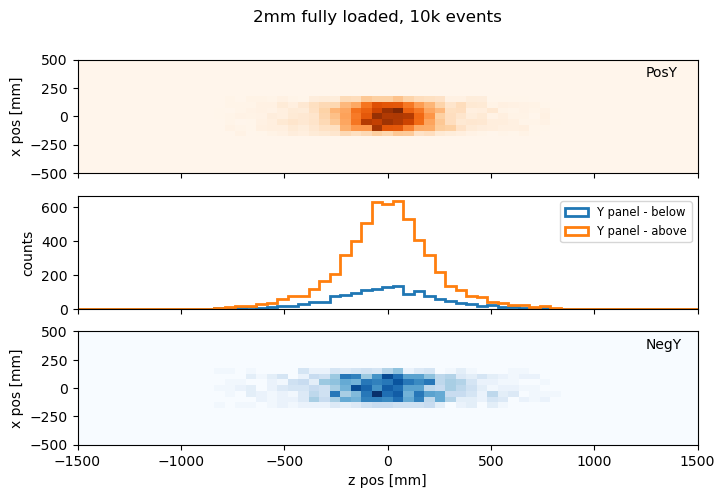

In [4]:
zpos_fully_2mm, zneg_fully_2mm = plot_photons_vs_distance(df_2mm_fully_10k,  title='2mm fully loaded, 10k events', get_hist=True)

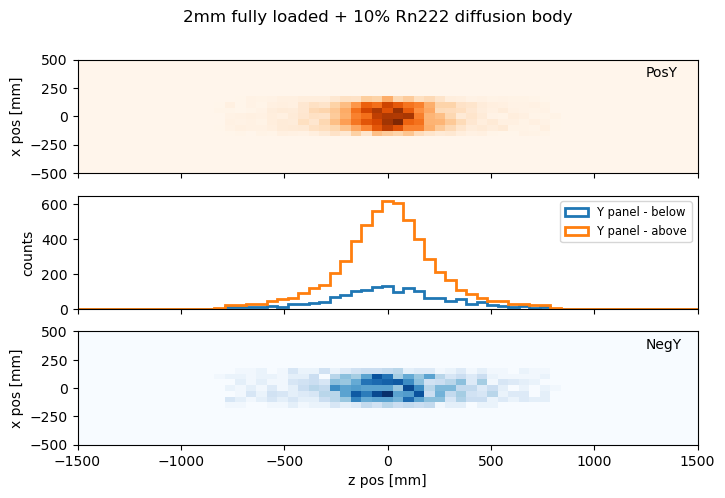

In [5]:
df_2mm_fully_10k_diff_10 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_10diffRn222_photon_boundaries.csv")
zneg_diff10, zpos_diff10 = plot_photons_vs_distance(df_2mm_fully_10k_diff_10, get_hist=True, title='2mm fully loaded + 10% Rn222 diffusion body')

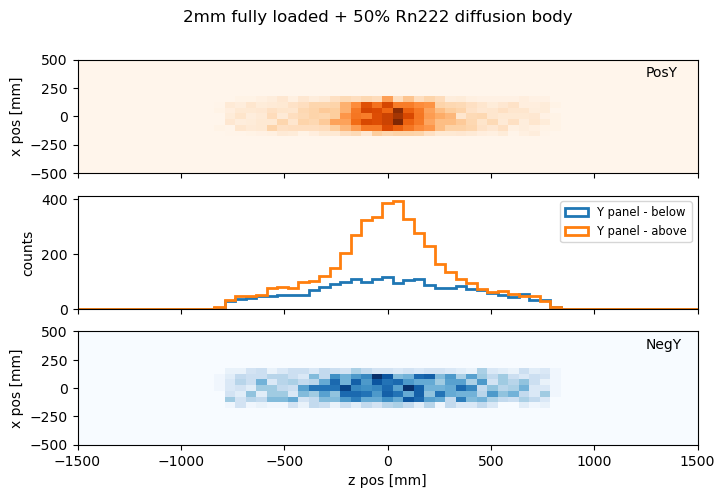

In [6]:
df_2mm_fully_10k_diff_50 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_50diffRn222_photon_boundaries.csv")
zneg_diff50, zpos_diff50 = plot_photons_vs_distance(df_2mm_fully_10k_diff_50, get_hist=True, 
                                                    title='2mm fully loaded + 50% Rn222 diffusion body')

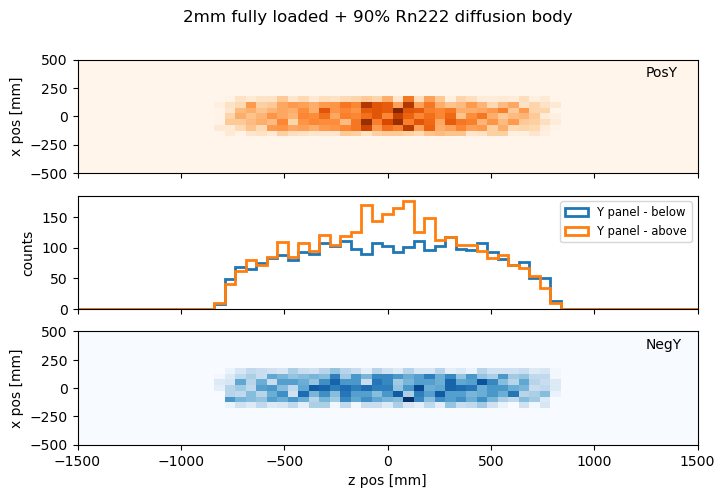

In [7]:
df_2mm_fully_10k_diff_90 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_90diffRn222_photon_boundaries.csv")
zneg_diff90, zpos_diff90 = plot_photons_vs_distance(df_2mm_fully_10k_diff_90, get_hist=True, 
                                                    title='2mm fully loaded + 90% Rn222 diffusion body')

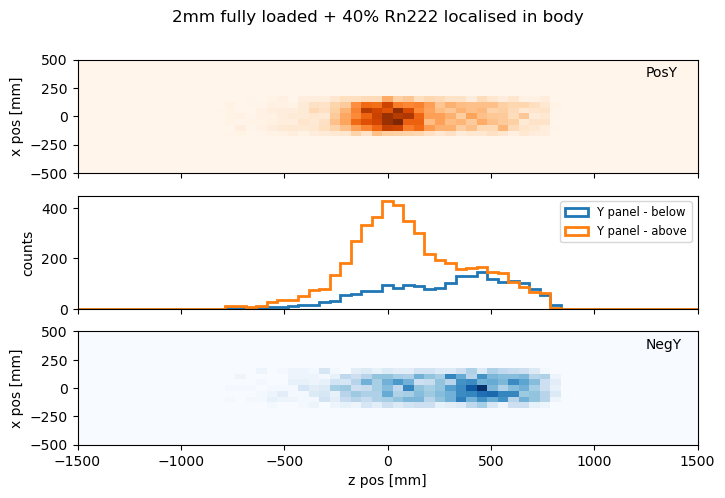

In [8]:
df_2mm_fully_10k_40_loc = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_40_Rn222_loc_photon_boundaries.csv")
zneg_40_loc, zpos_40_loc = plot_photons_vs_distance(df_2mm_fully_10k_40_loc, get_hist=True, 
                                                    title='2mm fully loaded + 40% Rn222 localised in body',
                                                    figname="2mm_fully_40rn222loc_yprofile.png")


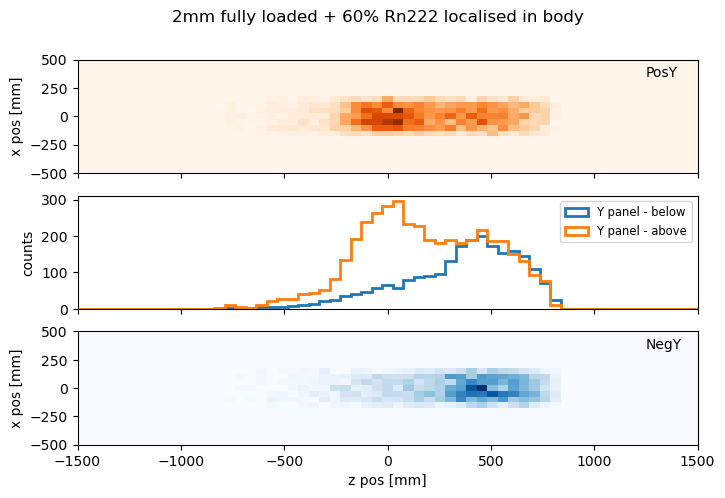

In [9]:
df_2mm_fully_10k_60_loc = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_60_Rn222_loc_photon_boundaries.csv")
zneg_60_loc, zpos_60_loc = plot_photons_vs_distance(df_2mm_fully_10k_60_loc, get_hist=True, 
                                                    title='2mm fully loaded + 60% Rn222 localised in body')

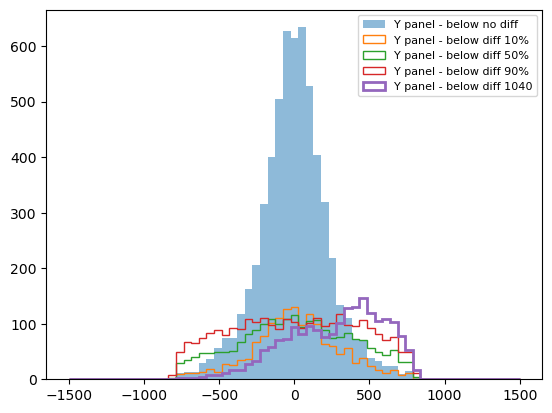

In [10]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zneg_fully_2mm, bins=bins, label='Y panel - below no diff', linewidth=1, alpha=.5)
plt.hist(zneg_diff10, bins=bins, histtype=u'step', label='Y panel - below diff 10%', linewidth=1)
plt.hist(zneg_diff50, bins=bins, histtype=u'step', label='Y panel - below diff 50%', linewidth=1)
plt.hist(zneg_diff90, bins=bins, histtype=u'step', label='Y panel - below diff 90%', linewidth=1)
plt.hist(zneg_40_loc, bins=bins, histtype=u'step', label='Y panel - below diff 1040', linewidth=2)
plt.legend(fontsize=8)
plt.show()

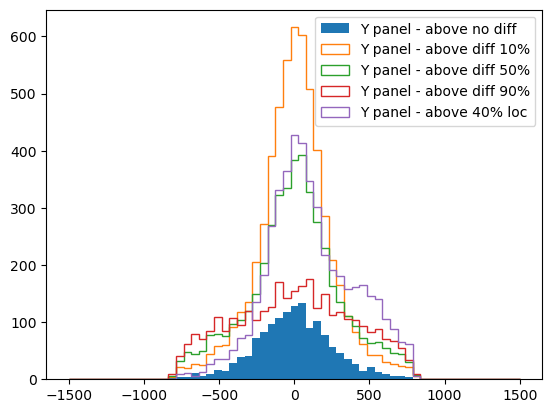

In [11]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zpos_fully_2mm, bins=bins, label='Y panel - above no diff', linewidth=1)
plt.hist(zpos_diff10, bins=bins, histtype=u'step', label='Y panel - above diff 10%', linewidth=1)
plt.hist(zpos_diff50, bins=bins, histtype=u'step', label='Y panel - above diff 50%', linewidth=1)
plt.hist(zpos_diff90, bins=bins, histtype=u'step', label='Y panel - above diff 90%', linewidth=1)
plt.hist(zpos_40_loc, bins=bins, histtype=u'step', label='Y panel - above 40% loc', linewidth=1)
plt.legend()
plt.show()

In [12]:
df_2mm_fully_10k[]

SyntaxError: invalid syntax (1696877885.py, line 1)

In [ ]:
test = df_2mm_fully_10k[(df_2mm_fully_10k(['volumeName'].str.contains('physPhotonDetector')))  & (df_2mm_fully_10k['boundary']=='enter')].copy()

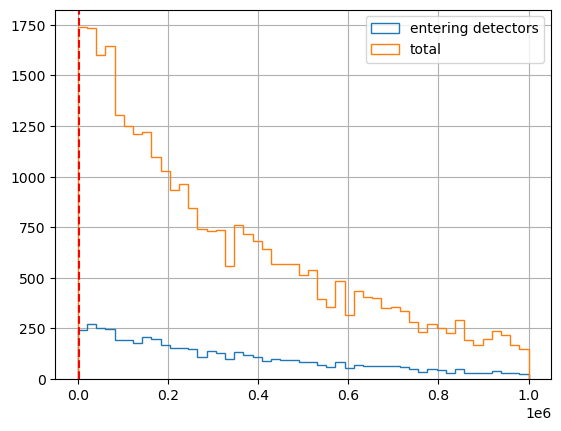

In [ ]:
test['time_s'].hist(bins=np.linspace(0, 1e6, 50), histtype='step', label='entering detectors')
df_2mm_fully_10k['time_s'].hist(bins=np.linspace(0, 1e6, 50), histtype='step', label='total')
plt.axvline(x=1800, linestyle='--', c='red')
plt.legend()
plt.show()